# Simple ML: Predict CCD Accuracy and Response Time from Evoked (-2, 0)
This notebook extracts per-subject evoked responses for the `contrastChangeDetection` task with epoch window [-2, 0] s, builds simple features, and fits basic regression models to predict participants' `ccd_accuracy` (ACC) and `ccd_response_time` (RES).

## load data

In [ ]:
# Imports & logging
from pathlib import Path
import numpy as np
import os
from mne import grand_average
from mne.time_frequency import psd_array_welch
sys.path.append(os.path.abspath("/mount/NAS-workspace-portal/eeg2025-Vistec/"))

from eegkit.utils.system.logging_utils import configure_logging, silence_console_logs
from eegkit.models.subject_model import EEGSubjectModel
from eegkit.controller.eeg_controller import EEGController
from eegkit.models.dtos import TaskDTO, SubjectFilterDTO
from eegkit.models.dtos import EpochPSDParamsDTO
from eegkit.utils.channels import prepare_channels

configure_logging('INFO')
silence_console_logs('WARNING')

### Setup

In [2]:
DATA_DIR = Path(os.getenv("DATA_DIR") or os.getenv("EEG_DATA_DIR") or "")
if not DATA_DIR or not DATA_DIR.exists():
    raise FileNotFoundError("Set DATA_DIR to your BIDS root containing cmi_bids_R*/ directories.")

subject_model = EEGSubjectModel(DATA_DIR)
controller = EEGController(subject_model)

In [3]:
# Parameters: subjects, channels, and evoked window
N_SUBJECTS = 500  # use first N subjects
CHANNELS = "69-76,81-83,88,89"  # explicit posterior channels

# Epoch/PSD params (we'll compute SNR from PSD on epochs in [-2, 0] s)
params = EpochPSDParamsDTO(
    tmin=-2.0,
    tmax=0.0,
    stimulus=[None],
    channels=CHANNELS,
    notch=None,
    uv_min=None,
    uv_max=None,
    clean_flatline_sec=None,
    clean_hf_noise_sd_max=None,
    clean_corr_min=None,
    clean_asr_max_std=None,
    clean_power_min_sd=None,
    clean_power_max_sd=None,
    clean_max_outbound_pct=None,
    clean_window_sec=None,
)
print(f"Subjects: {N_SUBJECTS}, Channels: {CHANNELS}")

Subjects: 500, Channels: 69-76,81-83,88,89


## Load

In [4]:
group_dto = SubjectFilterDTO(task='contrastChangeDetection', subject_limit=N_SUBJECTS)
all_task_dtos = subject_model.get_filter_subjects_dto(group_dto)

seen = set()
selected_dtos = []
for dto in all_task_dtos:
    if dto.subject in seen:
        continue
    seen.add(dto.subject)
    selected_dtos.append(dto)
    if len(selected_dtos) >= N_SUBJECTS:
        break

selected_subjects = [d.subject for d in selected_dtos]
print(f"Selected subjects ({len(selected_subjects)}):", selected_subjects[:10])

Selected subjects (500): ['sub-NDARAA948VFH', 'sub-NDARAB678VYW', 'sub-NDARAB793GL3', 'sub-NDARAC904DMU', 'sub-NDARAD774HAZ', 'sub-NDARAE828CML', 'sub-NDARAG143ARJ', 'sub-NDARAG340ERT', 'sub-NDARAG788YV9', 'sub-NDARAK770XEW']


In [5]:
def snr_spectrum(
        psd: np.ndarray,
        noise_n_neighbor_freqs: int = 3,
        noise_skip_neighbor_freqs: int = 1,
) -> np.ndarray:
    """Compute SNR by dividing PSD by a neighborhood-averaged noise estimate."""
    kernel = np.concatenate(
        (
            np.ones(noise_n_neighbor_freqs),
            np.zeros(2 * noise_skip_neighbor_freqs + 1),
            np.ones(noise_n_neighbor_freqs),
        )
    )
    kernel /= kernel.sum()
    mean_noise = np.apply_along_axis(
        lambda psd_: np.convolve(psd_, kernel, mode="valid"),
        axis=-1,
        arr=psd,
    )
    edge_width = noise_n_neighbor_freqs + noise_skip_neighbor_freqs
    pad = [(0, 0)] * (mean_noise.ndim - 1) + [(edge_width, edge_width)]
    mean_noise = np.pad(mean_noise, pad_width=tuple(pad), constant_values=float("nan"))
    return psd / mean_noise


In [6]:
# Build one SNR feature vector per subject by averaging across ALL CCD runs
snr_list, ok_subjects = [], []
task_name = 'contrastChangeDetection'
global_freqs = None

for subj in selected_subjects:
    subj_tasks = subject_model.list_tasks(subj)
    runs = [r for (t, r) in subj_tasks if t == task_name] or [None]

    snr_runs = []
    for run in runs:
        dto = TaskDTO(subject=subj, task=task_name, run=run)
        epochs, _labels = controller.get_epochs(dto, params)
        if epochs is None:
            continue
        try:
            epochs.load_data()
        except Exception as e:
            print("Error processing subject " + subj + ": " + str(e))
            continue
        epochs = prepare_channels(epochs, params)
        sfreq = epochs.info["sfreq"]
        spectrum = epochs.compute_psd(
            method="welch",
            n_fft=int(max(8, sfreq * (params.tmax - params.tmin))),  # minimal n_fft safeguard
            n_overlap=0,
            n_per_seg=None,
            fmin=4,
            fmax=30,
            window="hann",
            average='mean',
            verbose=False,
        )
        psd, freq = spectrum.get_data(return_freqs=True)
        # Reduce PSD to 1D (avg across epochs/channels) so shapes are stable across runs
        if psd.ndim == 3:
            psd_1d = np.nanmean(psd, axis=(0, 1))
        elif psd.ndim == 2:
            psd_1d = np.nanmean(psd, axis=0)
        else:
            psd_1d = psd
        snr_1d = snr_spectrum(psd_1d)
        if not np.isfinite(snr_1d).any():
            continue

        # Ensure a global, consistent frequency grid across all subjects/runs
        if global_freqs is None:
            global_freqs = freq
        if len(freq) != len(global_freqs) or not np.allclose(freq, global_freqs, rtol=0.0, atol=1e-9):
            snr_1d = np.interp(global_freqs, freq, snr_1d, left=np.nan, right=np.nan)
            if not np.isfinite(snr_1d).any():
                continue

        # Replace NaNs (welch edge padding) with the run's finite mean
        finite = np.isfinite(snr_1d)
        fill = float(np.nanmean(snr_1d[finite])) if np.any(finite) else 0.0
        snr_1d = np.where(finite, snr_1d, fill).astype(np.float32)
        snr_runs.append(snr_1d)

    if not snr_runs:
        continue

    if len(snr_runs) == 1:
        snr_avg = snr_runs[0]
    else:
        stack = np.stack(snr_runs, axis=0)
        valid = np.isfinite(stack)
        counts = valid.sum(axis=0)
        sums = np.where(valid, stack, 0.0).sum(axis=0)
        snr_avg = sums / np.maximum(1, counts)
    snr_list.append(snr_avg)
    ok_subjects.append(subj)

df_meta = subject_model.get_subjects_metadata(ok_subjects, columns=['ccd_accuracy','ccd_response_time'])
df_meta = df_meta.set_index('participant_id').loc[ok_subjects]
y_df = df_meta[['ccd_accuracy','ccd_response_time']].copy()
y = y_df.astype(float).values
X = np.stack(snr_list, axis=0)
mask = np.isfinite(y).all(axis=1)
X = X[mask]
y = y[mask]
ok_subjects = [s for i, s in enumerate(ok_subjects) if bool(mask[i])]

## Model

### ML

In [7]:
import numpy as np
import time

In [8]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (500, 53)
y shape: (500, 2)


In [14]:
save_path = Path(f"/mount/NAS-workspace-portal/eeg2025-Vistec/models/data/X_snr_{N_SUBJECTS}_{time.time()}.npy")
np.save(save_path, X)

print("Saved to", save_path)

Saved to /mount/NAS-workspace-portal/eeg2025-Vistec/models/data/X_snr_500_1771167863.7117176.npy


In [15]:
save_path = Path(f"/mount/NAS-workspace-portal/eeg2025-Vistec/models/data/Y_snr_{N_SUBJECTS}_{time.time()}.npy")
np.save(save_path, y)

print("Saved to", save_path)

Saved to /mount/NAS-workspace-portal/eeg2025-Vistec/models/data/Y_snr_500_1771167865.7485447.npy


In [9]:
y = np.asarray(y)
y_acc = y[:, 0] 
y_rt  = y[:, 1]

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_absolute_error

# Define pipeline
pipe = make_pipeline(StandardScaler(), Ridge())

# Define hyperparameter grid
param_grid = {
    "ridge__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Grid search
grid = GridSearchCV(pipe, param_grid, cv=kf, scoring="neg_mean_absolute_error")
grid.fit(X, y)

print("Best alpha:", grid.best_params_)
print("Best CV MAE:", -grid.best_score_)

Best alpha: {'ridge__alpha': 100.0}
Best CV MAE: 8.75134518303501


In [11]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X)

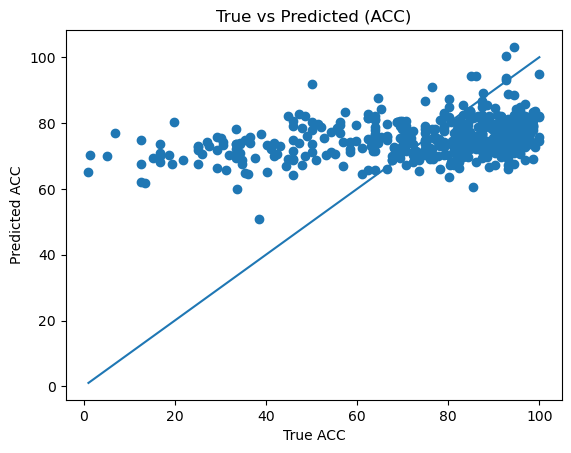

In [12]:
plt.figure()
plt.scatter(y[:,0], y_pred[:,0])
plt.xlabel("True ACC")
plt.ylabel("Predicted ACC")
plt.title("True vs Predicted (ACC)")
plt.plot([y[:,0].min(), y[:,0].max()],
         [y[:,0].min(), y[:,0].max()])
plt.show()


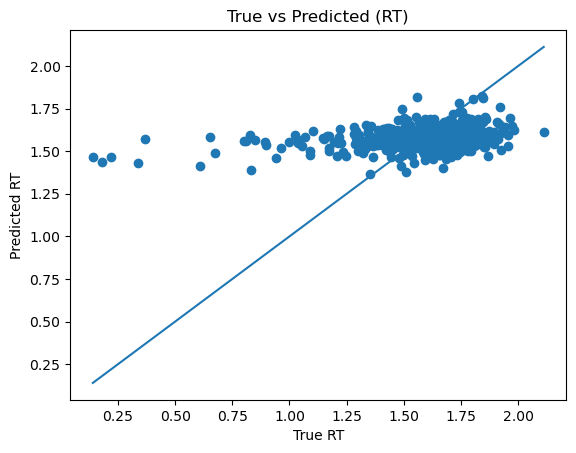

In [13]:
plt.figure()
plt.scatter(y[:,1], y_pred[:,1])
plt.xlabel("True RT")
plt.ylabel("Predicted RT")
plt.title("True vs Predicted (RT)")
plt.plot([y[:,1].min(), y[:,1].max()],
         [y[:,1].min(), y[:,1].max()])
plt.show()


In [16]:
import joblib
import time
model_path = Path(f"/mount/NAS-workspace-portal/eeg2025-Vistec/models/ml/snr_model_{N_SUBJECTS}_{time.time()}.pkl")
joblib.dump(best_model, model_path)
print(f"Model saved to {model_path}")

Model saved to /mount/NAS-workspace-portal/eeg2025-Vistec/models/ml/snr_model_500_1771167871.4968765.pkl


### Deep Learing